# Лабораторна робота 2

**Датасет:** CIC-IDS2017 (як у ЛР1)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Підготовка даних

In [2]:
df = pd.read_csv('../Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv')

df.columns = df.columns.str.strip()
df['Label'] = df['Label'].str.strip().str.replace('\ufffd', '-', regex=False)

TARGET = 'Label'
features = [c for c in df.columns if c != TARGET]

num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

const_cols = [c for c in features if df[c].nunique() == 1]
df = df.drop(columns=const_cols)

df['Label_bin'] = (df[TARGET] != 'BENIGN').astype(int)
df['Label_short'] = df[TARGET].str.replace('Web Attack - ', '', regex=False)

print('Dataset size:', df.shape)

Dataset size: (170366, 71)


In [3]:
attacks = df[df['Label_bin'] == 1]
benign = df[df['Label_bin'] == 0].sample(n=len(attacks), random_state=42)

data = pd.concat([attacks, benign]).sample(frac=1, random_state=42).reset_index(drop=True)

X = data.drop(columns=[TARGET, 'Label_short', 'Label_bin'])
y = data['Label_bin']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_train)

X_train_sc = scaler.transform(X_train)
X_test_sc = scaler.transform(X_test)

print('Working sample:', data.shape)
print('X_train_sc:', X_train_sc.shape, '  X_test_sc:', X_test_sc.shape)

Working sample: (4360, 71)
X_train_sc: (3052, 68)   X_test_sc: (1308, 68)


# Завдання 1. Зниження розмірності та візуалізація

## 1.1 PCA: пояснена дисперсія

In [4]:
from sklearn.decomposition import PCA

pca_full = PCA().fit(X_train_sc)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

for t in [0.80, 0.90, 0.95, 0.99]:
    print(f'{t:.0%} of variance: {np.argmax(cum_var >= t) + 1:2d} components')

80% of variance: 11 components
90% of variance: 16 components
95% of variance: 20 components
99% of variance: 29 components


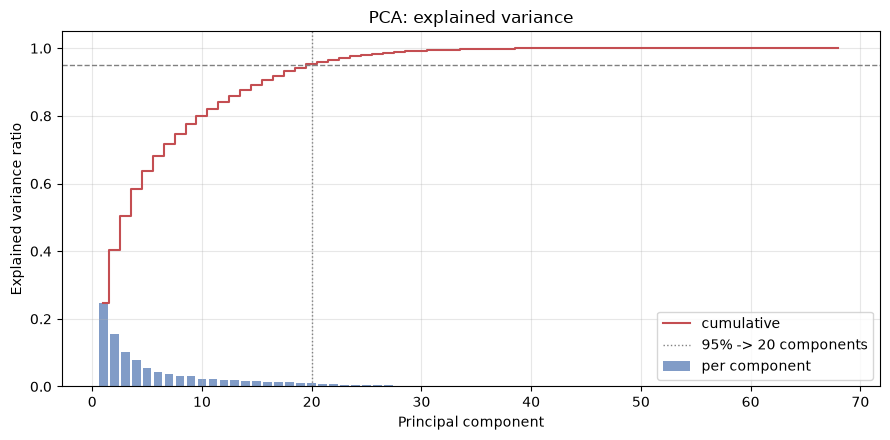

In [5]:
n_95 = np.argmax(cum_var >= 0.95) + 1
idx = np.arange(1, len(cum_var) + 1)

plt.figure(figsize=(9, 4.5))
plt.bar(idx, pca_full.explained_variance_ratio_, color='#4C72B0', alpha=0.7, label='per component')
plt.step(idx, cum_var, where='mid', color='#C44E52', label='cumulative')
plt.axhline(0.95, color='gray', linestyle='--', linewidth=1)
plt.axvline(n_95, color='gray', linestyle=':', linewidth=1, label=f'95% -> {n_95} components')
plt.xlabel('Principal component')
plt.ylabel('Explained variance ratio')
plt.title('PCA: explained variance')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 1.2 Зниження розмірності

In [6]:
start = time.perf_counter()
pca = PCA(n_components=0.95).fit(X_train_sc)
pca_time = time.perf_counter() - start

X_train_pca = pca.transform(X_train_sc)
X_test_pca = pca.transform(X_test_sc)

print('Features before:', X_train_sc.shape[1], '  after:', pca.n_components_)
print(f'Explained variance: {pca.explained_variance_ratio_.sum():.4f}')
print(f'PCA fit time: {pca_time * 1000:.1f} ms')

Features before: 68   after: 20
Explained variance: 0.9527
PCA fit time: 2.7 ms


In [7]:
loadings = pd.DataFrame(pca.components_[:2].T, index=X.columns, columns=['PC1', 'PC2'])

for pc in ['PC1', 'PC2']:
    print(pc)
    print(loadings[pc].abs().sort_values(ascending=False).head(6).round(3).to_string())
    print()

PC1
Max Packet Length         0.200
Packet Length Mean        0.198
Bwd Packet Length Max     0.197
Packet Length Std         0.196
Avg Bwd Segment Size      0.195
Bwd Packet Length Mean    0.195

PC2
Flow IAT Std     0.263
Fwd IAT Mean     0.250
Flow IAT Mean    0.243
Bwd IAT Mean     0.241
Fwd IAT Max      0.229
Flow IAT Max     0.228



## 1.3 Класифікація до і після PCA

In [8]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def run_svm(X_tr, X_te, repeats=5):
    fit_times, pred_times = [], []
    for _ in range(repeats):
        model = SVC(kernel='rbf', C=100, gamma=1, random_state=42)

        start = time.perf_counter()
        model.fit(X_tr, y_train)
        fit_times.append(time.perf_counter() - start)

        start = time.perf_counter()
        p = model.predict(X_te)
        pred_times.append(time.perf_counter() - start)

    return model, p, np.median(fit_times), np.median(pred_times)

def score_row(name, X_tr, model, p, fit_time, pred_time):
    return {
        'Model': name,
        'Features': X_tr.shape[1],
        'Accuracy': accuracy_score(y_test, p),
        'Precision': precision_score(y_test, p),
        'Recall': recall_score(y_test, p),
        'F1': f1_score(y_test, p),
        'Support vectors': model.n_support_.sum(),
        'Fit, ms': fit_time * 1000,
        'Predict, ms': pred_time * 1000,
    }

In [9]:
svm_raw, p_raw, fit_raw, pred_raw = run_svm(X_train_sc, X_test_sc)
svm_pca, p_pca, fit_pca, pred_pca = run_svm(X_train_pca, X_test_pca)

results = pd.DataFrame([
    score_row('SVM (before PCA)', X_train_sc, svm_raw, p_raw, fit_raw, pred_raw),
    score_row('SVM + PCA', X_train_pca, svm_pca, p_pca, fit_pca, pred_pca),
]).set_index('Model')

print(results.round(4).T)

Model            SVM (before PCA)  SVM + PCA
Features                  68.0000    20.0000
Accuracy                   0.9901     0.9901
Precision                  0.9938     0.9938
Recall                     0.9862     0.9862
F1                         0.9900     0.9900
Support vectors          675.0000   607.0000
Fit, ms                   60.8408    50.6468
Predict, ms               43.3225    35.3544


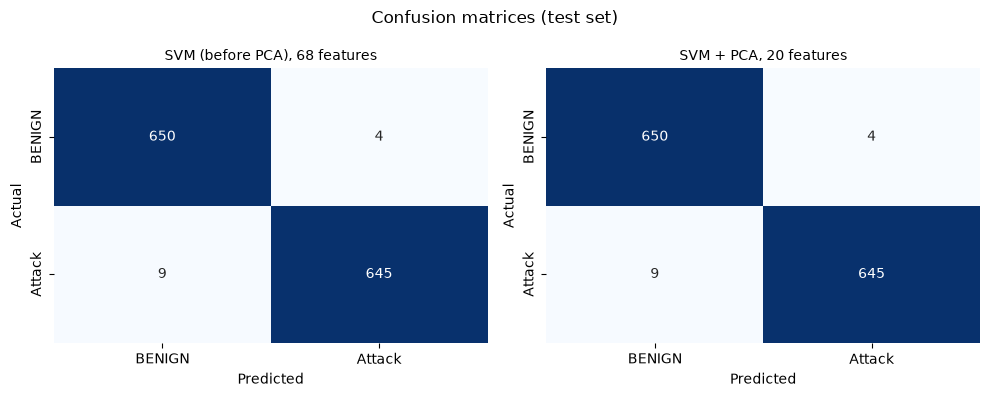

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, p) in zip(axes, [('SVM (before PCA)', p_raw), ('SVM + PCA', p_pca)]):
    sns.heatmap(confusion_matrix(y_test, p), annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['BENIGN', 'Attack'], yticklabels=['BENIGN', 'Attack'], ax=ax)
    ax.set_title(f'{name}, {results.loc[name, "Features"]} features', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

fig.suptitle('Confusion matrices (test set)')
plt.tight_layout()
plt.show()

## 1.4 Залежність від кількості компонент

In [11]:
n_list = [2, 3, 5, 8, 10, 15, 20, 30, 40, 50, X_train_sc.shape[1]]
sweep = []

for n in n_list:
    p_n = PCA(n_components=n).fit(X_train_sc)
    model, p, fit_t, _ = run_svm(p_n.transform(X_train_sc), p_n.transform(X_test_sc), repeats=3)
    sweep.append({'Components': n,
                  'Variance': p_n.explained_variance_ratio_.sum(),
                  'F1': f1_score(y_test, p),
                  'Support vectors': model.n_support_.sum(),
                  'Fit, ms': fit_t * 1000})

sweep = pd.DataFrame(sweep).set_index('Components')
print(sweep.round(4))

            Variance      F1  Support vectors  Fit, ms
Components                                            
2             0.4037  0.9496              348  42.4317
3             0.5051  0.9766              261  33.4321
5             0.6375  0.9901              112  13.2044
8             0.7463  0.9908              107  13.3140
10            0.7990  0.9893              115  12.3918
15            0.8917  0.9900              527  51.8963
20            0.9527  0.9900              607  54.2644
30            0.9931  0.9900              672  65.9179
40            0.9994  0.9900              674  55.2859
50            1.0000  0.9900              674  49.1320
68            1.0000  0.9900              675  55.4621


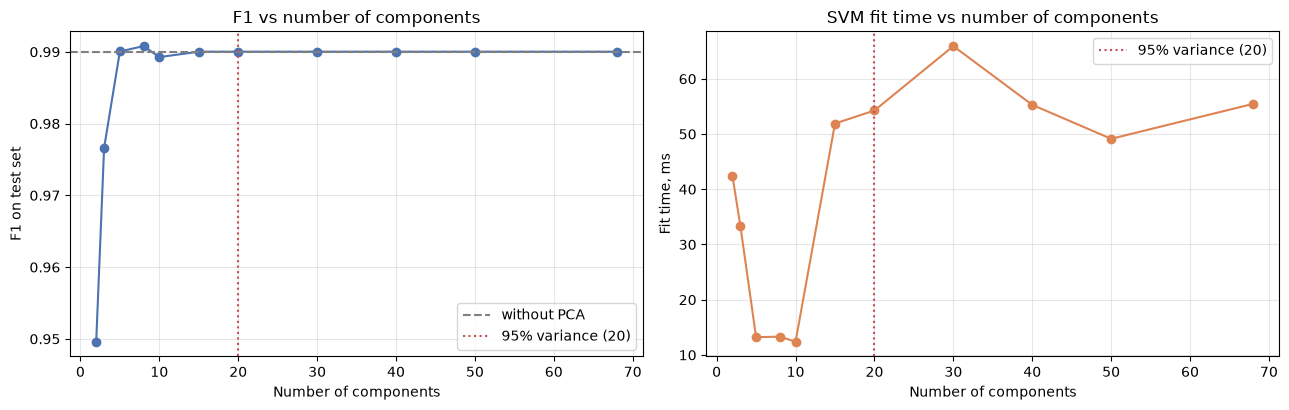

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].plot(sweep.index, sweep['F1'], marker='o', color='#4C72B0')
axes[0].axhline(results.loc['SVM (before PCA)', 'F1'], color='gray', linestyle='--', label='without PCA')
axes[0].set_ylabel('F1 on test set')
axes[0].set_title('F1 vs number of components')

axes[1].plot(sweep.index, sweep['Fit, ms'], marker='o', color='#DD8452')
axes[1].set_ylabel('Fit time, ms')
axes[1].set_title('SVM fit time vs number of components')

for ax in axes:
    ax.axvline(pca.n_components_, color='#C44E52', linestyle=':', label=f'95% variance ({pca.n_components_})')
    ax.set_xlabel('Number of components')
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

In [13]:
before = results.loc['SVM (before PCA)']
after = results.loc['SVM + PCA']

print(f'Features:  {int(before["Features"])} -> {int(after["Features"])}  '
      f'({1 - after["Features"] / before["Features"]:.0%} fewer)')
print(f'F1:        {before["F1"]:.4f} -> {after["F1"]:.4f}  ({after["F1"] - before["F1"]:+.4f})')
print(f'Fit time:  {before["Fit, ms"]:.1f} -> {after["Fit, ms"]:.1f} ms  '
      f'(x{before["Fit, ms"] / after["Fit, ms"]:.2f})  + PCA {pca_time * 1000:.1f} ms')
print(f'Predict:   {before["Predict, ms"]:.1f} -> {after["Predict, ms"]:.1f} ms')

Features:  68 -> 20  (71% fewer)
F1:        0.9900 -> 0.9900  (+0.0000)
Fit time:  60.8 -> 50.6 ms  (x1.20)  + PCA 2.7 ms
Predict:   43.3 -> 35.4 ms


### Висновок

PCA скоротив ознаки з 68 до 20 (на 71 %) при збереженні 95 % дисперсії, бо багато ознак дублюють одна одну. Якість SVM не змінилась: F1 = 0.990, матриця помилок та сама. Уже 5 компонент дають такий самий результат. Час навчання майже не змінився (≈61 → ≈51 мс), бо для SVM важить кількість опорних векторів (675 → 607), а не ознак.

## 1.5 Візуалізація: t-SNE

In [14]:
from sklearn.manifold import TSNE

X_all_sc = StandardScaler().fit_transform(X)
labels = data['Label_short'].values

start = time.perf_counter()
X_tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=42).fit_transform(X_all_sc)
print(f't-SNE: {X_all_sc.shape} -> {X_tsne.shape} in {time.perf_counter() - start:.1f} s')

pca_2d = PCA(n_components=2).fit(X_all_sc)
X_pca2 = pca_2d.transform(X_all_sc)
print(f'PCA 2D explained variance: {pca_2d.explained_variance_ratio_.sum():.3f}')

t-SNE: (4360, 68) -> (4360, 2) in 4.7 s
PCA 2D explained variance: 0.402


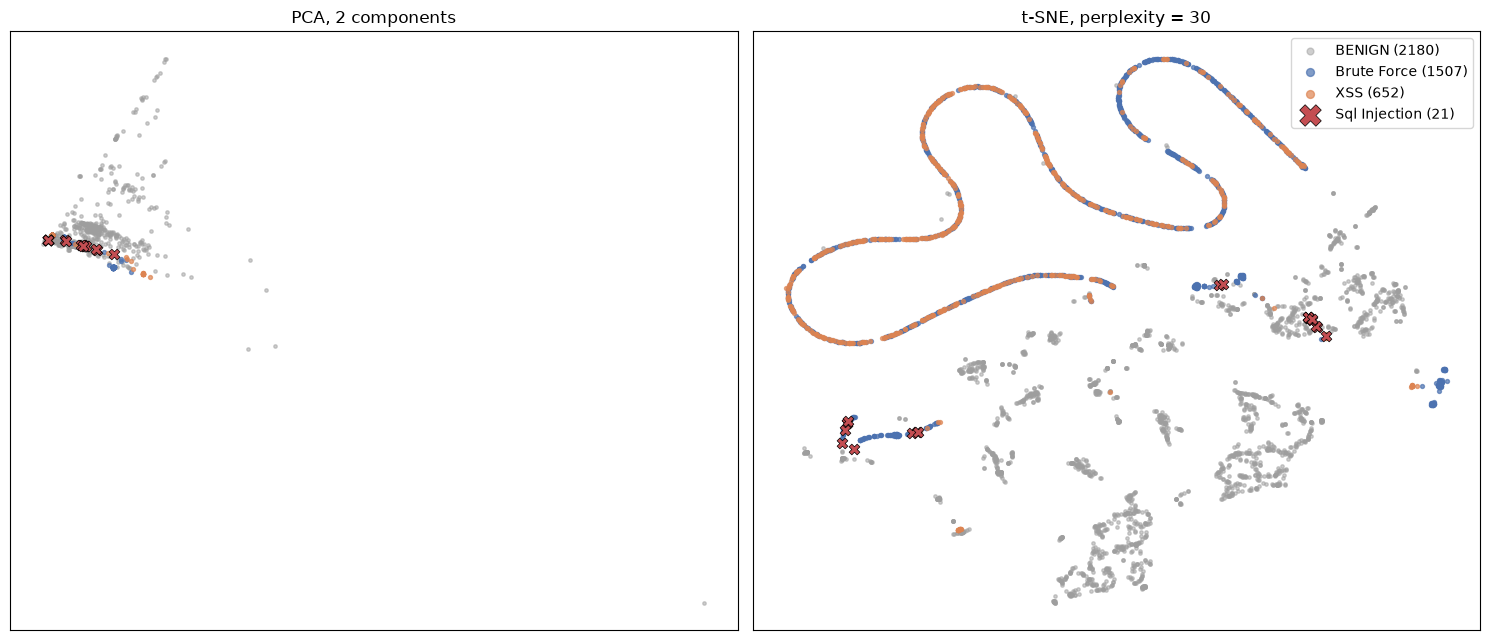

In [15]:
order = ['BENIGN', 'Brute Force', 'XSS', 'Sql Injection']
style = {
    'BENIGN':        dict(c='#9E9E9E', s=6,  marker='o', alpha=0.5),
    'Brute Force':   dict(c='#4C72B0', s=8,  marker='o', alpha=0.7),
    'XSS':           dict(c='#DD8452', s=8,  marker='o', alpha=0.7),
    'Sql Injection': dict(c='#C44E52', s=60, marker='X', alpha=1.0, edgecolors='black', linewidths=0.5),
}

def plot_embedding(ax, emb, title):
    for cls in order:
        m = labels == cls
        ax.scatter(emb[m, 0], emb[m, 1], label=f'{cls} ({m.sum()})', **style[cls])
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
plot_embedding(axes[0], X_pca2, 'PCA, 2 components')
plot_embedding(axes[1], X_tsne, 't-SNE, perplexity = 30')
axes[1].legend(markerscale=2, loc='best')
plt.tight_layout()
plt.show()

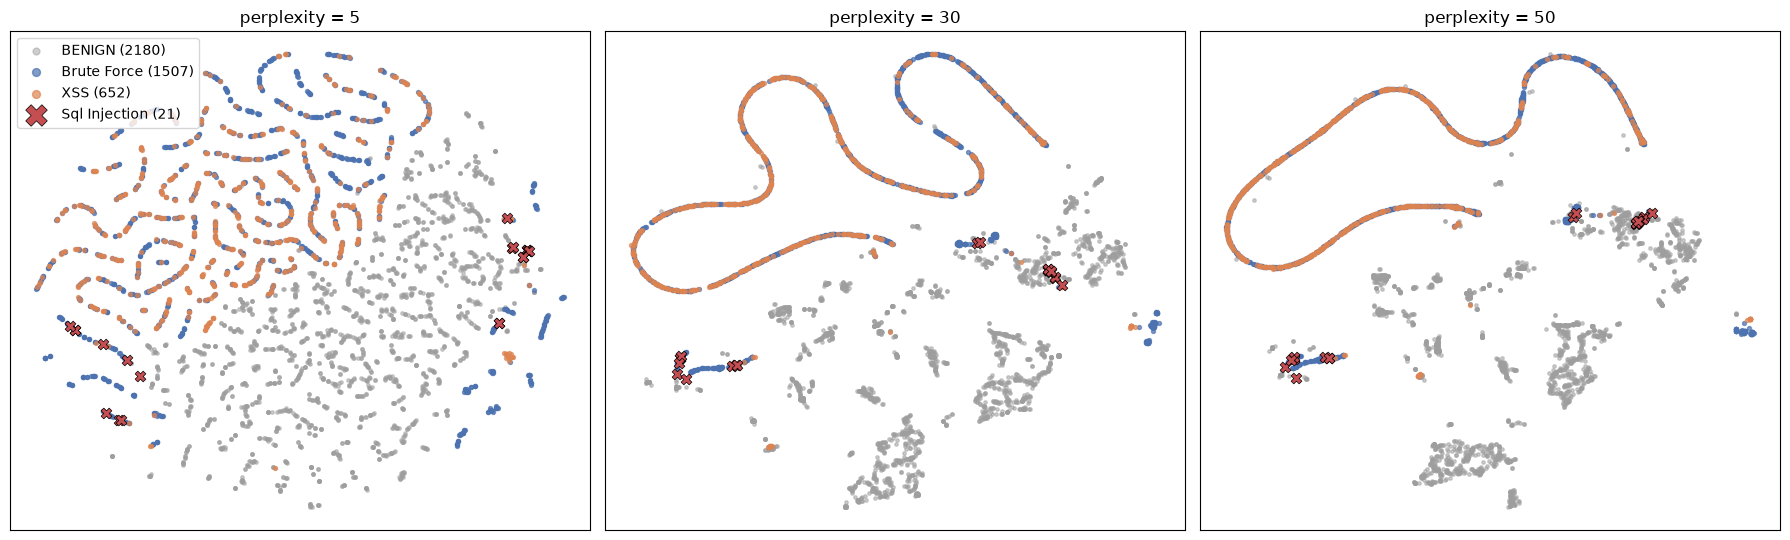

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, perp in zip(axes, [5, 30, 50]):
    emb = X_tsne if perp == 30 else TSNE(n_components=2, perplexity=perp, init='pca',
                                         random_state=42).fit_transform(X_all_sc)
    plot_embedding(ax, emb, f'perplexity = {perp}')

axes[0].legend(markerscale=2, loc='best')
plt.tight_layout()
plt.show()

### Висновок

BENIGN розпадається на десятки острівців — різні види трафіку (DNS, HTTPS, LDAP). Атаки витягнуті в окрему довгу криву: їх генерував один інструмент, тому потоки майже однакові. Через це в ЛР1 F1 ≈ 0.99. Brute Force і XSS перемішані — за мережевими ознаками вони не відрізняються. PCA у 2D пояснює лише 40 % дисперсії, і класи на ньому накладаються.

# Завдання 2. Кластерний аналіз

## 2.1 Вибір класів

In [17]:
keep = (data['Label_short'] != 'Sql Injection').values

X_cl = X[keep].reset_index(drop=True)
true_cl = data.loc[keep, 'Label_short'].reset_index(drop=True)
classes = ['BENIGN', 'Brute Force', 'XSS']

print('X_cl:', X_cl.shape)
print(true_cl.value_counts())

X_cl: (4339, 68)
Label_short
BENIGN         2180
Brute Force    1507
XSS             652
Name: count, dtype: int64


## 2.2 Масштабування

In [18]:
X_cl_std = StandardScaler().fit_transform(X_cl)
X_cl_log = StandardScaler().fit_transform(np.sign(X_cl) * np.log1p(np.abs(X_cl)))

print('max |z|, std:     ', np.abs(X_cl_std).max().round(1))
print('max |z|, log+std: ', np.abs(X_cl_log).max().round(1))

max |z|, std:      60.3
max |z|, log+std:  14.9


## 2.3 Вибір кількості кластерів: Elbow і Silhouette

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)
elbow = []

for space, Z in [('std', X_cl_std), ('log+std', X_cl_log)]:
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Z)
        elbow.append({'Space': space, 'k': k,
                      'Inertia': km.inertia_,
                      'Silhouette': silhouette_score(Z, km.labels_),
                      'Smallest cluster': np.bincount(km.labels_).min()})

elbow = pd.DataFrame(elbow)
print(elbow.pivot(index='k', columns='Space').round(3))

          Inertia             Silhouette        Smallest cluster     
Space     log+std         std    log+std    std          log+std  std
k                                                                    
2      191771.481  234706.025      0.492  0.630              711  479
3      114401.446  204452.228      0.573  0.625              719    1
4       88949.326  175851.422      0.620  0.597              719    1
5       72146.290  156885.497      0.636  0.428              341    1
6       63313.200  142360.777      0.653  0.447               99    1
7       56589.243  130020.441      0.662  0.460               99    1
8       50731.538  119666.368      0.673  0.529               58    1
9       44326.612  111453.846      0.689  0.560               58    1
10      39427.186  107217.228      0.663  0.556               58    1


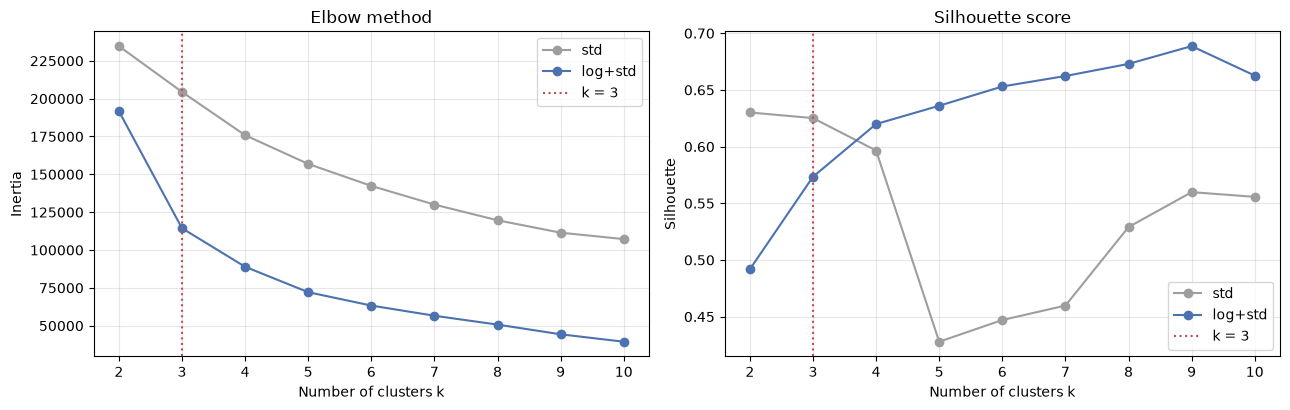

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

for space, color in [('std', '#9E9E9E'), ('log+std', '#4C72B0')]:
    part = elbow[elbow['Space'] == space]
    axes[0].plot(part['k'], part['Inertia'], marker='o', color=color, label=space)
    axes[1].plot(part['k'], part['Silhouette'], marker='o', color=color, label=space)

axes[0].set_title('Elbow method')
axes[0].set_ylabel('Inertia')
axes[1].set_title('Silhouette score')
axes[1].set_ylabel('Silhouette')

for ax in axes:
    ax.axvline(3, color='#C44E52', linestyle=':', label='k = 3')
    ax.set_xlabel('Number of clusters k')
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

In [21]:
K = 3
kmeans = KMeans(n_clusters=K, n_init=10, random_state=42).fit(X_cl_log)
clusters = kmeans.labels_

print('Cluster sizes:', np.bincount(clusters))
print(f'Silhouette: {silhouette_score(X_cl_log, clusters):.3f}')

Cluster sizes: [1877 1743  719]
Silhouette: 0.573


## 2.4 Візуалізація кластерів (t-SNE)

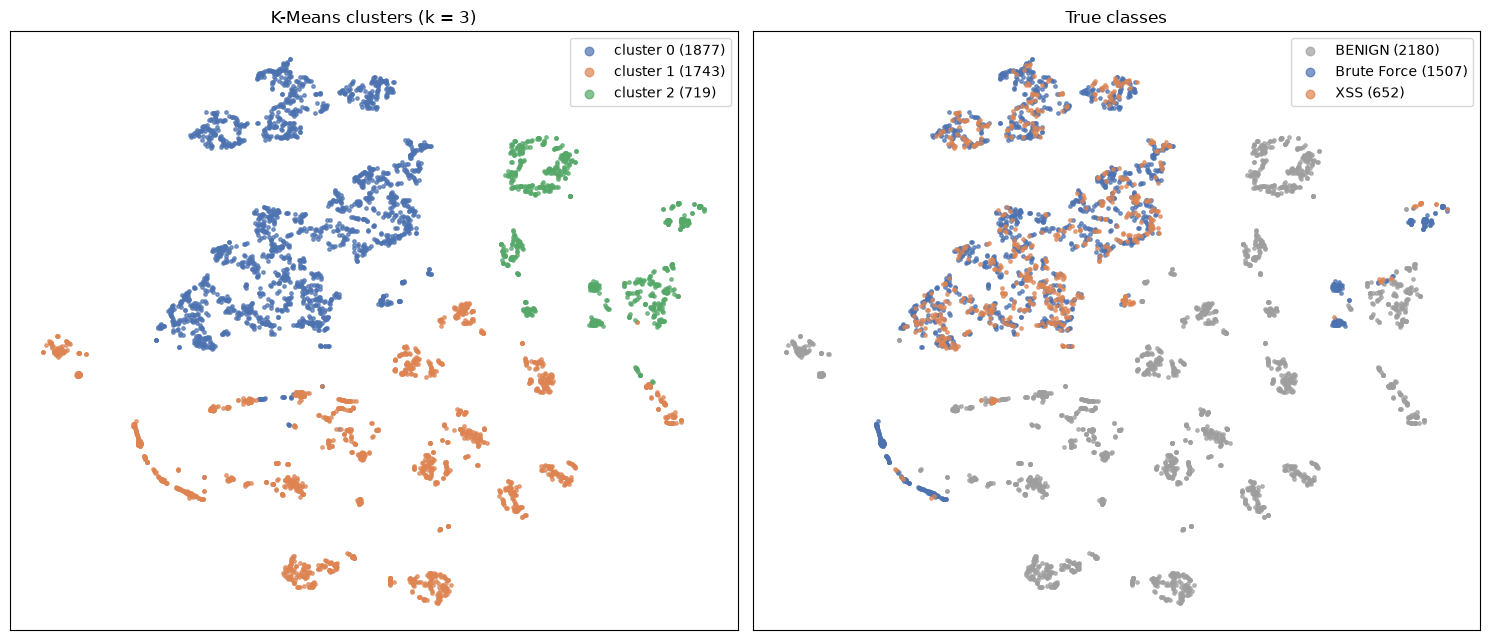

In [22]:
X_cl_tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=42).fit_transform(X_cl_log)

cluster_colors = ['#4C72B0', '#DD8452', '#55A868']
class_colors = {'BENIGN': '#9E9E9E', 'Brute Force': '#4C72B0', 'XSS': '#DD8452'}

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

for c in range(K):
    m = clusters == c
    axes[0].scatter(X_cl_tsne[m, 0], X_cl_tsne[m, 1], s=6, alpha=0.7,
                    c=cluster_colors[c], label=f'cluster {c} ({m.sum()})')

for cls in classes:
    m = (true_cl == cls).values
    axes[1].scatter(X_cl_tsne[m, 0], X_cl_tsne[m, 1], s=6, alpha=0.7,
                    c=class_colors[cls], label=f'{cls} ({m.sum()})')

axes[0].set_title('K-Means clusters (k = 3)')
axes[1].set_title('True classes')
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(markerscale=2.5)

plt.tight_layout()
plt.show()

## 2.5 Порівняння кластерів зі справжніми класами

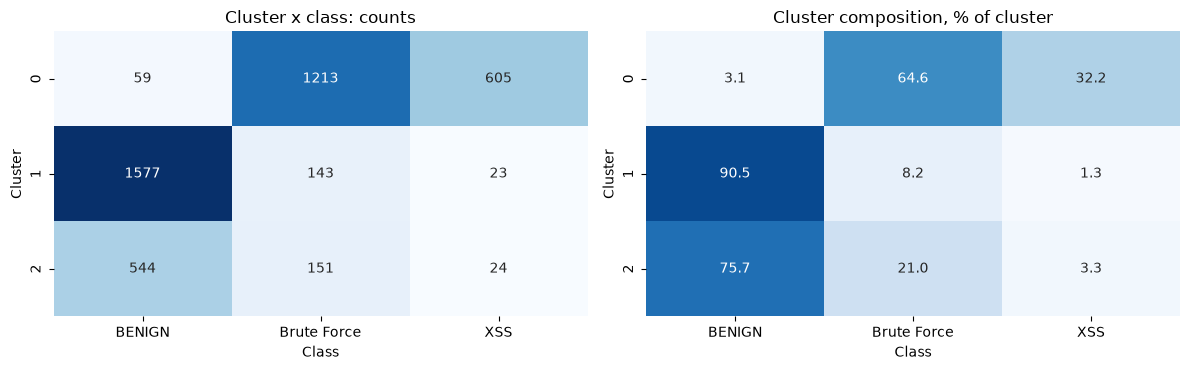

In [23]:
ct = pd.crosstab(clusters, true_cl, rownames=['Cluster'], colnames=['Class'])[classes]
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('Cluster x class: counts')

sns.heatmap(ct_pct, annot=True, fmt='.1f', cmap='Blues', cbar=False, vmin=0, vmax=100, ax=axes[1])
axes[1].set_title('Cluster composition, % of cluster')

plt.tight_layout()
plt.show()

In [24]:
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                             homogeneity_score, completeness_score)

true_bin = np.where(true_cl == 'BENIGN', 'BENIGN', 'Attack')

agreement = pd.DataFrame([{
    'Labels': name,
    'ARI': adjusted_rand_score(t, clusters),
    'NMI': normalized_mutual_info_score(t, clusters),
    'Homogeneity': homogeneity_score(t, clusters),
    'Completeness': completeness_score(t, clusters),
} for name, t in [('3 classes', true_cl), ('Attack / BENIGN', true_bin)]]).set_index('Labels')

print(agreement.round(3))

                   ARI    NMI  Homogeneity  Completeness
Labels                                                  
3 classes        0.418  0.416        0.422         0.410
Attack / BENIGN  0.554  0.482        0.598         0.404


In [25]:
profile_cols = ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
                'Total Length of Bwd Packets', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward',
                'PSH Flag Count', 'Fwd IAT Std']

print(X_cl.groupby(clusters)[profile_cols].median().T.round(1))
print()

for c in range(K):
    ports = X_cl.loc[clusters == c, 'Destination Port'].value_counts().head(5)
    print(f'Cluster {c}, top ports:', ports.to_dict())

                                     0      1           2
Destination Port                  80.0   53.0       139.0
Flow Duration                5485286.0  272.0  33954782.0
Total Fwd Packets                  3.0    2.0        13.0
Total Backward Packets             1.0    1.0        12.0
Total Length of Bwd Packets        0.0   81.0      4074.0
Init_Win_bytes_forward         29200.0   -1.0     29200.0
Init_Win_bytes_backward        28960.0   -1.0       288.0
PSH Flag Count                     1.0    0.0         1.0
Fwd IAT Std                  3872135.8    0.0   2181514.9

Cluster 0, top ports: {80: 1853, 443: 14, 0: 2, 60234: 1, 4273: 1}
Cluster 1, top ports: {53: 932, 80: 241, 443: 127, 123: 41, 137: 9}
Cluster 2, top ports: {443: 347, 80: 303, 53: 34, 123: 12, 22: 7}


In [26]:
ari_by_k = []
for k in k_range:
    labels_k = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X_cl_log)
    ari_by_k.append({'k': k,
                     'ARI (3 classes)': adjusted_rand_score(true_cl, labels_k),
                     'ARI (Attack / BENIGN)': adjusted_rand_score(true_bin, labels_k)})

print(pd.DataFrame(ari_by_k).set_index('k').round(3))

    ARI (3 classes)  ARI (Attack / BENIGN)
k                                         
2            -0.031                  0.026
3             0.418                  0.554
4             0.308                  0.473
5             0.305                  0.474
6             0.296                  0.469
7             0.297                  0.469
8             0.292                  0.465
9             0.284                  0.461
10            0.226                  0.416


### Висновок

Кластери відповідають класам лише частково: ARI = 0.55 для «атака / не атака» і 0.42 для трьох класів. K-Means розділив потоки за типом з'єднання:
- кластер 0 — HTTP-з'єднання без відповіді сервера: 97 % атак;
- кластер 1 — короткі запити, переважно DNS: 90 % BENIGN;
- кластер 2 — довгі TCP-сесії з даними: 76 % BENIGN.

Brute Force і XSS K-Means не розрізняє, бо різниця між ними лише у змісті HTTP-запиту. Кластер і клас не зобов'язані збігатися: K-Means знаходить найсильнішу структуру даних — тип з'єднання, а не мітку атаки.

# Завдання 3. Обробка та класифікація текстових даних

**Датасет:** IMDB Movie Reviews

## 3.1 Завантаження даних

In [27]:
import re
from collections import Counter

reviews = pd.read_csv('../IMDB_Dataset.csv')

print('Size:', reviews.shape)
print('Duplicates:', reviews.duplicated('review').sum())

reviews = reviews.drop_duplicates('review').reset_index(drop=True)
print('After dropping duplicates:', reviews.shape)
print()
print(reviews['sentiment'].value_counts())

Size: (50000, 2)
Duplicates: 418
After dropping duplicates: (49582, 2)

sentiment
positive    24884
negative    24698
Name: count, dtype: int64


In [28]:
print(reviews.loc[1, 'review'][:500])

A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly writte


## 3.2 Передобробка

In [29]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

NEGATIONS = {'not', 'no', 'nor', 'never', 'nothing', 'cannot'}
STOP_WORDS = (ENGLISH_STOP_WORDS - NEGATIONS) | {'br'}

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = text.replace("n't", ' not')
    text = re.sub(r'[^a-z\s]', ' ', text)
    return ' '.join(w for w in text.split() if w not in STOP_WORDS and len(w) > 1)

reviews['clean'] = reviews['review'].map(clean_text)
reviews['label'] = (reviews['sentiment'] == 'positive').astype(int)

print(reviews.loc[1, 'clean'][:400])
print()
print('Words per review, before:', round(reviews['review'].str.split().str.len().mean()),
      '  after:', round(reviews['clean'].str.split().str.len().mean()))

wonderful little production filming technique unassuming old time bbc fashion gives comforting discomforting sense realism entire piece actors extremely chosen michael sheen not got polari voices pat truly seamless editing guided references williams diary entries not worth watching terrificly written performed piece masterful production great master comedy life realism really comes home little thi

Words per review, before: 231   after: 109


## 3.3 WordCloud: найчастіші слова

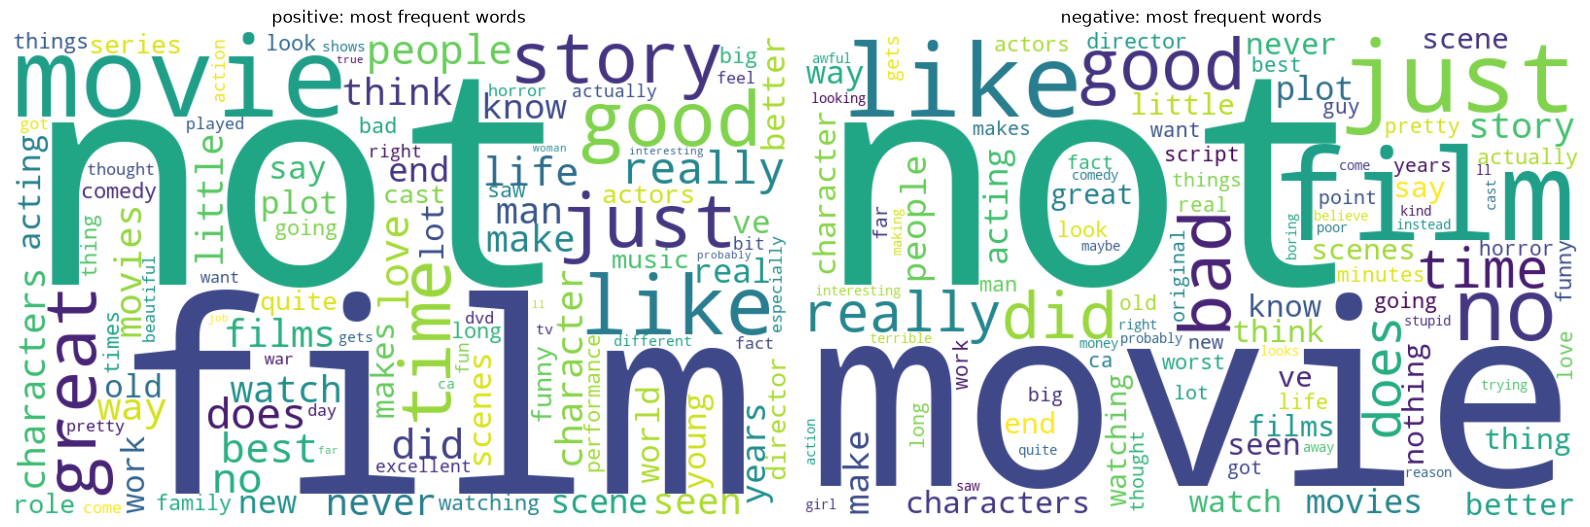

positive ['not', 'film', 'movie', 'like', 'good', 'just', 'story', 'great', 'time', 'really']
negative ['not', 'movie', 'film', 'like', 'just', 'no', 'good', 'bad', 'did', 'really']


In [30]:
from wordcloud import WordCloud

word_counts = {s: Counter(' '.join(reviews.loc[reviews['sentiment'] == s, 'clean']).split())
               for s in ['positive', 'negative']}

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

for ax, s in zip(axes, ['positive', 'negative']):
    wc = WordCloud(width=800, height=500, background_color='white', colormap='viridis',
                   max_words=100, random_state=42).generate_from_frequencies(word_counts[s])
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{s}: most frequent words')
    ax.axis('off')

plt.tight_layout()
plt.show()

for s in ['positive', 'negative']:
    print(s, [w for w, _ in word_counts[s].most_common(10)])

## 3.4 WordCloud: характерні слова і словосполучення

In [31]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(ngram_range=(1, 2), min_df=300)
counts = cv.fit_transform(reviews['clean'])
vocab = cv.get_feature_names_out()

is_pos = (reviews['label'] == 1).values
pos_freq = np.asarray(counts[is_pos].sum(axis=0)).ravel() + 1
neg_freq = np.asarray(counts[~is_pos].sum(axis=0)).ravel() + 1

log_odds = pd.Series(np.log(pos_freq / pos_freq.sum()) - np.log(neg_freq / neg_freq.sum()), index=vocab)

print('Vocabulary (words + bigrams):', len(vocab))
print('positive:', log_odds.nlargest(15).index.tolist())
print('negative:', log_odds.nsmallest(15).index.tolist())

Vocabulary (words + bigrams): 2767
positive: ['highly recommended', 'highly recommend', 'wonderfully', 'captures', 'delightful', 'beautifully', 'great job', 'underrated', 'superb', 'brilliantly', 'refreshing', 'extraordinary', 'outstanding', 'touching', 'friendship']
negative: ['worst movies', 'worst movie', 'worst film', 'waste time', 'not waste', 'waste', 'time money', 'just bad', 'unfunny', 'bad acting', 'worst', 'acting bad', 'bad movies', 'awful', 'redeeming']


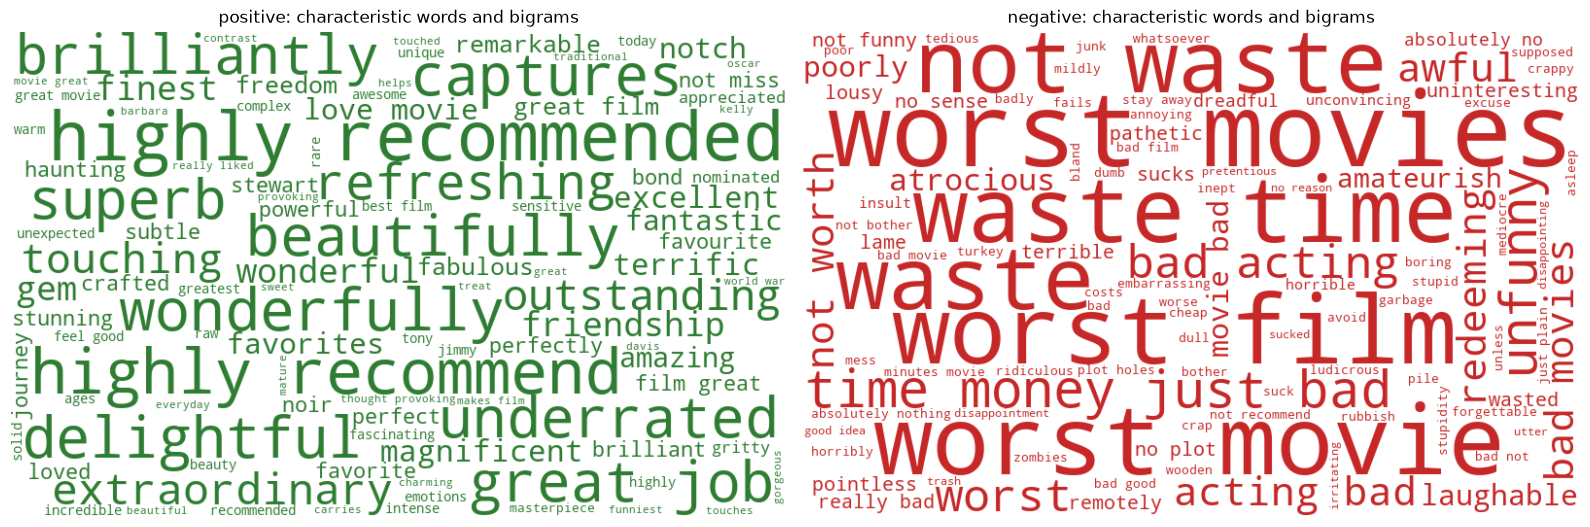

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

for ax, s, weights, color in [(axes[0], 'positive', log_odds.nlargest(100), '#2E7D32'),
                              (axes[1], 'negative', -log_odds.nsmallest(100), '#C62828')]:
    wc = WordCloud(width=800, height=500, background_color='white', max_words=100,
                   color_func=lambda *args, color=color, **kwargs: color,
                   random_state=42).generate_from_frequencies(weights.to_dict())
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{s}: characteristic words and bigrams')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 3.5 Векторизація: TF-IDF

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

X_txt_train, X_txt_test, y_txt_train, y_txt_test = train_test_split(
    reviews['clean'], reviews['label'], test_size=0.2, random_state=42, stratify=reviews['label'])

tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.9, sublinear_tf=True)

X_tf_train = tfidf.fit_transform(X_txt_train)
X_tf_test = tfidf.transform(X_txt_test)

print('Train:', X_tf_train.shape, '  Test:', X_tf_test.shape)
print(f'Non-zero values: {X_tf_train.nnz / np.prod(X_tf_train.shape):.4%}')

Train: (39665, 123007)   Test: (9917, 123007)
Non-zero values: 0.0980%


## 3.6 Навчання моделей

In [34]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_auc_score, classification_report

text_models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Linear SVM': LinearSVC(),
}

def text_scores(name, model, fit_time):
    p = model.predict(X_tf_test)
    s = model.predict_proba(X_tf_test)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_tf_test)
    return {'Model': name,
            'Accuracy': accuracy_score(y_txt_test, p),
            'Precision': precision_score(y_txt_test, p),
            'Recall': recall_score(y_txt_test, p),
            'F1': f1_score(y_txt_test, p),
            'ROC-AUC': roc_auc_score(y_txt_test, s),
            'Fit, s': fit_time}

text_results = []
for name, model in text_models.items():
    start = time.perf_counter()
    model.fit(X_tf_train, y_txt_train)
    text_results.append(text_scores(name, model, time.perf_counter() - start))

print(pd.DataFrame(text_results).set_index('Model').round(4).to_string())

                     Accuracy  Precision  Recall      F1  ROC-AUC  Fit, s
Model                                                                    
Naive Bayes            0.8859     0.8829  0.8907  0.8868   0.9520  0.0237
Logistic Regression    0.9011     0.8925  0.9128  0.9026   0.9658  0.5871
Linear SVM             0.9079     0.9032  0.9146  0.9089   0.9687  0.4204


## 3.7 Підбір C для логістичної регресії

In [35]:
from sklearn.model_selection import GridSearchCV

grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), {'C': [0.5, 1, 2, 4, 8, 16]},
                       scoring='f1', cv=5, n_jobs=-1)
grid_lr.fit(X_tf_train, y_txt_train)

print('Best C:', grid_lr.best_params_['C'])
print(f'Best F1 (CV): {grid_lr.best_score_:.4f}')

lr_best = grid_lr.best_estimator_
text_models['Logistic Regression (tuned)'] = lr_best
text_results.append(text_scores('Logistic Regression (tuned)', lr_best, grid_lr.refit_time_))

text_scores_df = pd.DataFrame(text_results).set_index('Model').sort_values('F1', ascending=False)
print()
print(text_scores_df.round(4).to_string())

Best C: 8
Best F1 (CV): 0.9064

                             Accuracy  Precision  Recall      F1  ROC-AUC  Fit, s
Model                                                                            
Logistic Regression (tuned)    0.9091     0.9037  0.9166  0.9101   0.9691  1.4826
Linear SVM                     0.9079     0.9032  0.9146  0.9089   0.9687  0.4204
Logistic Regression            0.9011     0.8925  0.9128  0.9026   0.9658  0.5871
Naive Bayes                    0.8859     0.8829  0.8907  0.8868   0.9520  0.0237


## 3.8 Оцінювання

              precision    recall  f1-score   support

    negative     0.9148    0.9016    0.9081      4940
    positive     0.9037    0.9166    0.9101      4977

    accuracy                         0.9091      9917
   macro avg     0.9092    0.9091    0.9091      9917
weighted avg     0.9092    0.9091    0.9091      9917



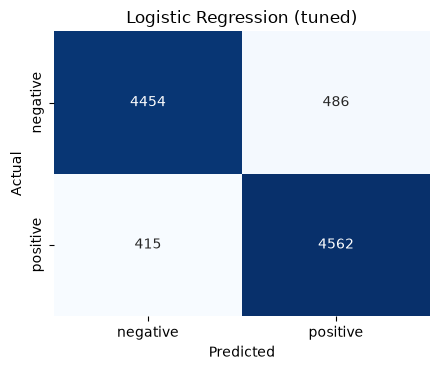

In [36]:
p_lr = lr_best.predict(X_tf_test)

print(classification_report(y_txt_test, p_lr, target_names=['negative', 'positive'], digits=4))

plt.figure(figsize=(4.5, 3.8))
sns.heatmap(confusion_matrix(y_txt_test, p_lr), annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['negative', 'positive'], yticklabels=['negative', 'positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression (tuned)')
plt.tight_layout()
plt.show()

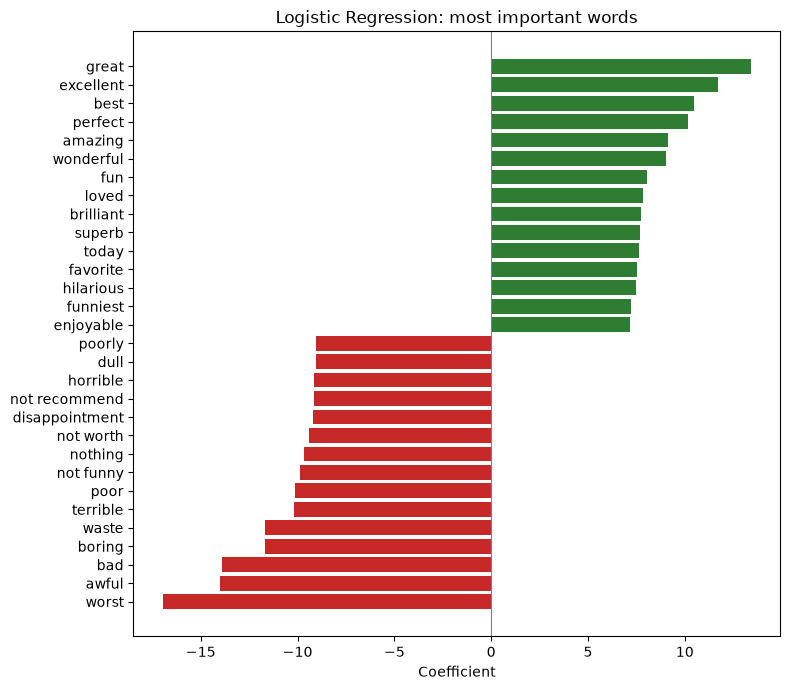

In [37]:
coefs = pd.Series(lr_best.coef_[0], index=tfidf.get_feature_names_out())
top_coefs = pd.concat([coefs.nsmallest(15), coefs.nlargest(15).iloc[::-1]])

plt.figure(figsize=(8, 7))
plt.barh(top_coefs.index, top_coefs.values,
         color=np.where(top_coefs.values > 0, '#2E7D32', '#C62828'))
plt.axvline(0, color='gray', linewidth=0.8)
plt.xlabel('Coefficient')
plt.title('Logistic Regression: most important words')
plt.tight_layout()
plt.show()

In [38]:
errors = X_txt_test.index[p_lr != y_txt_test.values]
print('Errors:', len(errors), 'of', len(y_txt_test))
print()

for i in errors[:3]:
    print(f"[{reviews.loc[i, 'sentiment']}]", reviews.loc[i, 'review'][:300])
    print()

Errors: 901 of 9917

[positive] This isn't exactly a great film, but I admire the writers and director for trying something a little different. The film's main theme is fate and small, seemingly insignificant things that can greatly change the future. In some ways this reminds me of the film SLIDING DOORS, though instead of focusi

[negative] Despite being a huge fan of Fred Astaire and Ginger Rogers' movies, it wasn't until about 6 years ago that I first saw 'Follow the Fleet'. I knew all the songs from an old Astaire/Rogers record (yes, vinyl) but knew nothing of the plot.<br /><br />Unfortunately, while the songs are catchy and Ginger

[negative] Writer & director Robert Downey, Sr., a pioneer of the underground film movement in the 1960s, satirized the New York Madison Avenue advertising world with his avant-garde comedy "Putney Swope." Downey doesn't confine his ridicule to advertising, but tackles black militant culture, the dynamics in H



### Висновок

Частотні хмари слів обох класів однакові (`not`, `movie`, `film`). Характерні слова видно лише при порівнянні класів: `highly recommend`, `superb` у позитивних відгуках і `worst movie`, `waste time`, `not worth` у негативних.

Найкраща модель - логістична регресія з C = 8. Linear SVM майже така сама, Naive Bayes слабший . Модель помиляється переважно на змішаних відгуках